# SVMs with Downsampling

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load in Data and Split Training and Testing Data

In [2]:
# Read in the cleaned CSV file
df = pd.read_csv('final_project_data.csv')

# Downsampling: Randomly sample 10000 instances from both class 0 and class 1
# Setting random_state ensures reproducibility for everyone in the group
df_class_0 = df[df['conversions'] == 0].sample(n=10000, random_state=42)
df_class_1 = df[df['conversions'] == 1].sample(n=10000, random_state=42)

# Concatenate the sampled data and shuffle (frac=1 returns 100% of the rows in random order)
df_subset = pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42).reset_index(drop=True)


# Separate independent and dependent variables
x = df.iloc[:, :-1]
y = df.loc[:, ['conversions']]

# Split the training and testing data with a ratio of 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Combine the balanced classes
df_balanced = pd.concat([df_class_0, df_class_1])

# Convert dependent variable to 1D array to work with sklearn
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()



### 3. Create a SVM classifier with linear kernel
Random search is used to optimize the hyperparameters since it takes significantly less time to run than grid search.

In [4]:
# Create SVM classifier with RBF kernel
model = svm.SVC(kernel='linear')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search.fit(x_train, y_train)

# Get best model
best_model = random_search.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred = best_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

Best Hyperparameters: {'gamma': 0.001, 'C': 1000}
                   precision    recall  f1-score   support

Not Converted (0)       1.00      0.98      0.99      2006
    Converted (1)       1.00      1.00      1.00     17994

         accuracy                           1.00     20000
        macro avg       1.00      0.99      0.99     20000
     weighted avg       1.00      1.00      1.00     20000



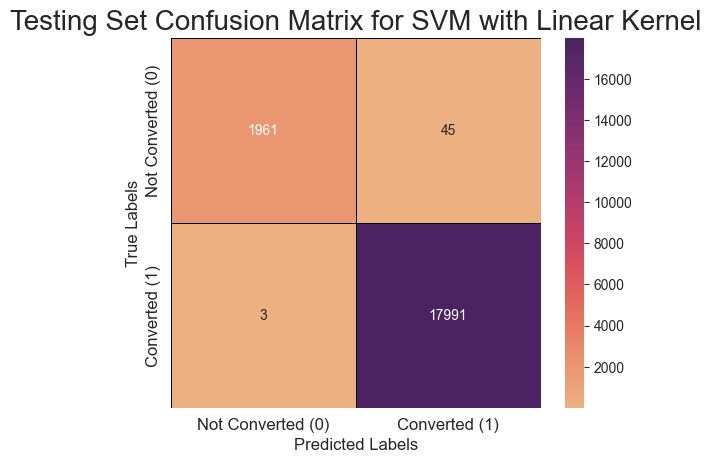

In [22]:
# Display best hyperparameters
print(f'Best Hyperparameters: {random_search.best_params_}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)'])
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

### 4. Create a SVM classifier with RBF kernel
Random search is used to optimize the hyperparameters since it takes significantly less time to run than grid search.

In [20]:
# Create SVM classifier with RBF kernel
rbf_model = svm.SVC(kernel='rbf')

# Specify hyperparameters to tune
param_dict = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

# Perform hyperparameter tuning with random search
random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
random_search_rbf.fit(x_train, y_train)

# Get best model
best_rbf_model = random_search_rbf.best_estimator_

# Make predictions on testing data with best hyperparameters
y_pred_rbf = best_rbf_model.predict(x_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/andreanaargyres/Documents/GitHub/ECS171-Group10/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .................................C=1000, gamma=0.1; total time=125.2min
[CV] END .................................C=1000, gamma=0.1; total time=125.3min
[CV] END .................................C=1000, gamma=0.1; total time=125.5min
[CV] END ..................................C=0.1, gamma=0.01; total time= 3.6min
[CV] END .....................................C=10, gamma=1; total time=129.4min
[CV] END .....................................C=10, gamma=1; total time=129.4min
[CV] END .....................................C=10, gamma=1; total time=129.5min
[CV] END .....................................C=10, gamma=1; total time=129.7min
[CV] END .....................................C=10, gamma=1; total time=129.7min
[CV] END ..................................C=0.1, gamma=0.01; total time= 4.2min
[CV] END .................................C=10, gamma=0.0001; total time= 3.7min
[CV] END .................................C=10, gamma=0.0001; total time= 3.7min
[CV] END ...................

In [1]:
# Display best hyperparameters
print(f'Best Hyperparameters: {random_search_rbf.best_params_}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'])
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

NameError: name 'random_search_rbf' is not defined